# 라이브러리

In [1]:
# 데이터 분석에 사용할 라이브러리
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로딩 관련 라이브러리
import os
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 평가용 라이브러리
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score
)

# 그래프 고해상도로 변경
%config InlineBackend.figure_format = 'retina'

# 마이너스 기호를 '-'로 표현하도록 변경
mpl.rc('axes', unicode_minus=False)

# Dataset load

In [2]:
# 현재 노트북 기준으로 프로젝트 루트를 찾아서 data 폴더 경로 고정
BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "data")

# okcupid 데이터셋 불러오기
dataset = pd.read_csv(os.path.join(DATA_PATH, "okcupid_profiles.csv"))

In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   status       59946 non-null  str    
 2   sex          59946 non-null  str    
 3   orientation  59946 non-null  str    
 4   body_type    54650 non-null  str    
 5   diet         35551 non-null  str    
 6   drinks       56961 non-null  str    
 7   drugs        45866 non-null  str    
 8   education    53318 non-null  str    
 9   ethnicity    54266 non-null  str    
 10  height       59943 non-null  float64
 11  income       59946 non-null  int64  
 12  job          51748 non-null  str    
 13  last_online  59946 non-null  str    
 14  location     59946 non-null  str    
 15  offspring    24385 non-null  str    
 16  pets         40025 non-null  str    
 17  religion     39720 non-null  str    
 18  sign         48890 non-null  str    
 19  smokes       54

In [4]:
dataset.head()

,age,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,...,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9
0,22,single,m,straight,a little extra,strictly anything,socially,never,working on college/university,"asian, white",...,about me: i would love to think that i was so...,currently working as an international agent fo...,making people laugh. ranting about a good salt...,"the way i look. i am a six foot half asian, ha...","books: absurdistan, the republic, of mice and ...",food. water. cell phone. shelter.,duality and humorous things,trying to find someone to hang out with. i am ...,i am new to california and looking for someone...,you want to be swept off your feet! you are ti...
1,35,single,m,straight,average,mostly other,often,sometimes,working on space camp,white,...,i am a chef: this is what that means. 1. i am ...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,i am die hard christopher moore fan. i don't r...,delicious porkness in all of its glories. my b...,NaN,NaN,i am very open and will share just about anyth...,NaN
2,38,available,m,straight,thin,anything,socially,NaN,graduated from masters program,NaN,...,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,okay this is where the cultural matrix gets so...,movement conversation creation contemplation t...,NaN,viewing. listening. dancing. talking. drinking...,"when i was five years old, i was known as ""the...","you are bright, open, intense, silly, ironic, ..."
3,23,single,m,straight,thin,vegetarian,socially,NaN,working on college/university,white,...,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,"bataille, celine, beckett. . . lynch, jarmusch...",NaN,cats and german philosophy,NaN,NaN,you feel so inclined.
4,29,single,m,straight,athletic,NaN,socially,never,graduated from college/university,"asian, black, other",...,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at: http://bagsbrown....,i smile a lot and my inquisitive nature,"music: bands, rappers, musicians at the moment...",NaN,NaN,NaN,NaN,NaN


# 학습 데이터 분석

## 이탈 의심자 (타겟) 분석

In [5]:
last_online_sort = dataset["last_online"].sort_values(ascending=False)
last_online_sort.head()

59873    2012-07-01-08-57
59819    2012-07-01-08-56
59842    2012-07-01-08-56
59838    2012-07-01-08-56
59826    2012-07-01-08-56
Name: last_online, dtype: str

In [6]:
# 기준 시각 개체 생성 (마지막 날짜)
criterion_date = pd.Timestamp("2012-07-01 09:00")

# 마지막 접속 시각 Timestamp 객체로 변환
# last_online은 결측치가 없음
TS_last_online = pd.to_datetime(
    dataset["last_online"],
    format="%Y-%m-%d-%H-%M"
)

# 60일 이상 미접속 여부 (1: 이탈 의심, 0: 쉬었음 청년)
dataset["churn_suspect"] = (
    (criterion_date - TS_last_online) >= pd.Timedelta(days=30)
).astype(int)

# 75:25
dataset["churn_suspect"].value_counts() / len(dataset)

churn_suspect
0    0.742785
1    0.257215
Name: count, dtype: float64

## 학습 / 테스트 분리

In [7]:
from common.preprocessing import train_test_split_by_target

X_train, X_test, Y_train, Y_test = train_test_split_by_target(
    dataset, "churn_suspect"
)

train_last_online = X_train["last_online"]
X_train.drop(columns="last_online", inplace=True)
X_test.drop(columns="last_online", inplace=True)

## 수치형 데이터 분석

In [8]:
train_num = X_train.select_dtypes(include=np.number)
train_num.describe()
# 109살 할아버지도 이용하는 갓앱
# 신장이 1인치인 태아도 연애에 관심 있음
# 수익이 -1이여도 연애는 하고싶을 수 있지

,age,height,income
count,44959.000000,44958.000000,44959.000000
mean,32.340710,68.302393,20000.081185
std,9.472268,4.019770,97022.702617
min,18.000000,1.000000,-1.000000
25%,26.000000,66.000000,-1.000000
50%,30.000000,68.000000,-1.000000
75%,37.000000,71.000000,-1.000000
max,110.000000,95.000000,1000000.000000


In [9]:
train_str = X_train.select_dtypes(exclude=np.number)
train_str.iloc[:,:14].describe()

# last_online을 제외하면 범주형 데이터가 맞음.

,status,sex,orientation,body_type,diet,drinks,drugs,education,ethnicity,job,location,offspring,pets,religion
count,44959,44959,44959,40960,26610,42717,34350,39955,40658,38789,44959,18368,30027,29752
unique,5,2,3,12,18,6,3,32,201,21,176,15,15,45
top,single,m,straight,average,mostly anything,socially,never,graduated from college/university,white,other,"san francisco, california",doesn't have kids,likes dogs and likes cats,agnosticism
freq,41794,26912,38766,10906,12462,31343,28268,17996,24446,5743,23273,5737,11100,2018


In [10]:
train_str.iloc[:,14:].describe()
# essay는 사용자가 직접 글을 쓰는 것이니 unique가 많을 수밖에 없는데, speaks는 왜..?

,sign,smokes,speaks,essay0,essay1,essay2,essay3,essay4,essay5,essay6,essay7,essay8,essay9
count,36687,40800,44921,40844,39249,37718,36349,37021,36794,34555,35612,30516,35468
unique,48,5,6057,40769,38654,36557,32848,36928,36705,32772,34250,29581,34136
top,gemini and it&rsquo;s fun to think about,no,english,.,enjoying it.,listening,my smile,ask me,my family,my future,out with friends,ask me,you want to.
freq,1332,32895,16357,10,44,61,385,12,5,116,69,36,149


In [11]:
train_str["speaks"].head(10)

52240                                              english
30039                                              english
52139                 english (fluently), spanish (poorly)
46257                            english, spanish (poorly)
24919                                              english
20567              english (fluently), portuguese (poorly)
28598                 english (fluently), spanish (poorly)
59146                                              english
32975    english (okay), spanish (poorly), japanese (po...
55743                                              english
Name: speaks, dtype: str

In [17]:
train_str["speaks"][49]   # c++ 유창하다니 부럽다

'english (fluently), spanish (okay)'

## Correlation Heatmap 

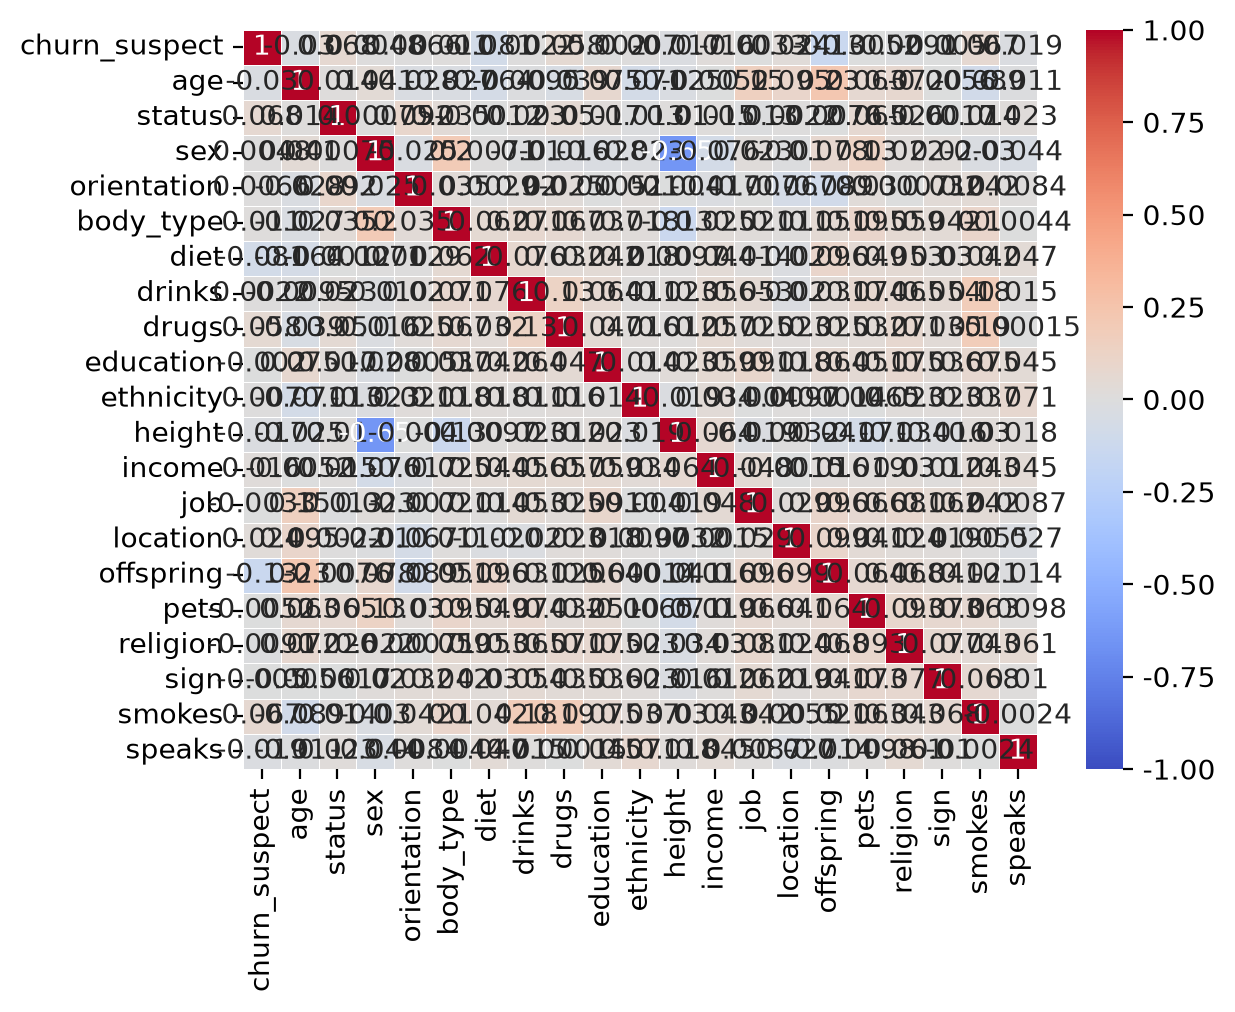

In [18]:
from common.show_graph import show_corr_map

essay_cols = [f"essay{i}" for i in range(10)]
show_corr_map(X_train, Y_train, essay_cols)

# EDA
- 성경님과 지수님이 짱 잘해주실거야 분명!!!

# Feature Extraction
- EDA만 잘하면 바로 만들 수 있지

In [19]:
import html

# 팀원이 선택한 최종 feature 14개
feature_list = [
    "actively_looking",
    "has_essay0",
    "essay_count",
    "profile_completeness",
    "religion_type",
    "edu_level",
    "wants_kids",
    "has_kids",
    "diet_type",
    "drugs_level",
    "job",
    "height",
    "status",
    "income"
]

# profile_completeness 계산에 사용하는 프로필 항목 (팀원 노트북과 동일)
PROFILE = [
    "body_type", "diet_type", "diet_strict", "drinks_level", "drugs_level",
    "edu_level", "edu_status", "ethnicity_main", "job", "has_kids",
    "wants_kids", "pets_dog", "pets_cat", "religion_type",
    "religion_serious", "smokes_level", "zodiac"
]
ESSAY = [f"essay{i}" for i in range(10)]
MISSING_ESSAY = r"(?i)^\s*(?:[.\-?_/]+|na|n/a)\s*$"

DRINKS = {"not at all": 0, "rarely": 1, "socially": 2,
          "often": 3, "very often": 4, "desperately": 4}
DRUGS = {"never": 0, "sometimes": 1, "often": 2}
SMOKES = {"no": 0, "trying to quit": 1, "when drinking": 2,
          "sometimes": 3, "yes": 4}
EDU_LEVELS = ["high school", "two-year college", "college/university",
              "masters program", "law school", "med school",
              "ph.d program", "space camp"]
RELIGIONS = ["agnosticism", "atheism", "christianity", "judaism",
             "catholicism", "islam", "hinduism", "buddhism", "other"]


def diet_type(x):
    if pd.isna(x):
        return None
    return x.replace("mostly ", "").replace("strictly ", "")


def diet_strict(x):
    if pd.isna(x):
        return None
    if x.startswith("strictly"):
        return "strictly"
    if x.startswith("mostly"):
        return "mostly"
    return "plain"


def has_kids(x):
    if pd.isna(x):
        return None
    if x.startswith("has"):
        return 1
    if "doesn't have kids" in x:
        return 0
    return None


def wants_kids(x):
    if pd.isna(x):
        return None
    if "might want" in x:
        return "maybe"
    if "doesn't want" in x:
        return "no"
    if "wants" in x:
        return "yes"
    return None


def pet_attitude(text, animal):
    if pd.isna(text):
        return None
    for word in ["has", "dislikes", "likes"]:
        if f"{word} {animal}" in text:
            return word
    return None


def edu_level(x):
    if pd.isna(x):
        return None
    for level in EDU_LEVELS:
        if level in x:
            return level
    return None


def edu_status(x):
    if pd.isna(x):
        return None
    for status in ["graduated from", "working on", "dropped out of"]:
        if x.startswith(status):
            return status
    return None


def religion_type(x):
    if pd.isna(x):
        return None
    for religion in RELIGIONS:
        if x.startswith(religion):
            return religion
    return None


def religion_serious(x):
    if pd.isna(x):
        return None
    if "very serious" in x:
        return "very"
    if "somewhat serious" in x:
        return "somewhat"
    if "not too serious" in x:
        return "not much"
    if "laughing about" in x:
        return "joking"
    return "unsaid"


def main_ethnicity(x):
    if pd.isna(x):
        return None
    return x.split(",")[0].strip()


def zodiac(x):
    if pd.isna(x):
        return None
    return x.split()[0]


# ------------------ #
# feature_extraction #
# ------------------ #
def feature_extraction(df: pd.DataFrame) -> pd.DataFrame:
    # 원본을 유지하면서 feature 생성
    result = df.copy()

    # -------- #
    # cleaning #
    # -------- #
    text_cols = result.select_dtypes(include=["object", "string"]).columns
    for col in text_cols:
        result[col] = result[col].map(
            lambda x: html.unescape(x) if isinstance(x, str) else x
        )
    result[text_cols] = result[text_cols].replace(r"^\s*$", np.nan, regex=True)
    result[ESSAY] = result[ESSAY].replace(MISSING_ESSAY, np.nan, regex=True)

    # HTML의 &rsquo;가 변환된 곡선 따옴표도 자녀 응답에서 정상 인식
    offspring = result["offspring"].str.replace("’", "'", regex=False)

    # ------------------ #
    # 기본 응답에서 파생 #
    # ------------------ #
    result["actively_looking"] = result["status"].isin(["single", "available"]).astype(int)
    result["drinks_level"] = result["drinks"].map(DRINKS)
    result["drugs_level"] = result["drugs"].map(DRUGS)
    result["smokes_level"] = result["smokes"].map(SMOKES)
    result["diet_type"] = result["diet"].apply(diet_type)
    result["diet_strict"] = result["diet"].apply(diet_strict)
    result["has_kids"] = offspring.apply(has_kids)
    result["wants_kids"] = offspring.apply(wants_kids)
    result["pets_dog"] = result["pets"].apply(lambda x: pet_attitude(x, "dogs"))
    result["pets_cat"] = result["pets"].apply(lambda x: pet_attitude(x, "cats"))
    result["edu_level"] = result["education"].apply(edu_level)
    result["edu_status"] = result["education"].apply(edu_status)
    result["religion_type"] = result["religion"].apply(religion_type)
    result["religion_serious"] = result["religion"].apply(religion_serious)
    result["ethnicity_main"] = result["ethnicity"].apply(main_ethnicity)
    result["zodiac"] = result["sign"].apply(zodiac)

    # 결측치를 채우기 전에 응답한 프로필 항목 비율 / 에세이 수 계산
    result["profile_completeness"] = result[PROFILE].notna().mean(axis=1)
    result["essay_count"] = result[ESSAY].notna().sum(axis=1)
    result["has_essay0"] = result["essay0"].notna().astype(int)

    # 기존 전처리와 동일하게 income=-1은 결측으로 간주
    result["income"] = result["income"].replace(-1, np.nan)

    return result


# 각 데이터를 독립적으로 feature extraction 후 최종 14개만 저장
train_all = feature_extraction(X_train)
test_all = feature_extraction(X_test)

X_train = train_all[feature_list].copy()
X_test = test_all[feature_list].copy()

print("feature 개수 :", len(feature_list))
print(feature_list)

feature 개수 : 14
['actively_looking', 'has_essay0', 'essay_count', 'profile_completeness', 'religion_type', 'edu_level', 'wants_kids', 'has_kids', 'diet_type', 'drugs_level', 'job', 'height', 'status', 'income']


In [20]:
# actively_looking은 위 feature_extraction()에서 생성됨

In [21]:
from common.preprocessing import soft_cleansing

# 필요한 feature를 생성한 뒤에만 결측치를 채움 (학습 데이터 기준)
X_train, X_test = soft_cleansing(X_train, X_test)

수정 전 train: 155926, test: 51826
수정 후 train: 0, test: 0


In [22]:
X_train.shape, X_test.shape

((44959, 14), (14987, 14))

In [23]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("feature list\n", X_train.columns)

X_train: (44959, 14)
X_test : (14987, 14)
feature list
 Index(['actively_looking', 'has_essay0', 'essay_count', 'profile_completeness',
       'religion_type', 'edu_level', 'wants_kids', 'has_kids', 'diet_type',
       'drugs_level', 'job', 'height', 'status', 'income'],
      dtype='str')


## Cleansing Check

In [24]:
print(f"X_train 결측치 수 : {X_train.isnull().sum().sum()}")
print(f"X_test 결측치 수 : {X_test.isnull().sum().sum()}")

X_train 결측치 수 : 0
X_test 결측치 수 : 0


# Data Preprocessing

In [25]:
from common.preprocessing import smotenc_sampling

# SMOTE를 쓰려면 essay는 물론 다른 컬럼들도 손봐야 함.

# Modeling

## Dimension Check

In [26]:
# 모델에게 학습시키기 전 차원 검증
assert X_train.shape[0] == Y_train.shape[0], "학습 데이터 수 != 타겟 데이터 수"
assert X_test.shape[0] == Y_test.shape[0], "테스트 데이터 수 != 타켓 데이터 수"
assert X_train.shape[1] == X_test.shape[1], "학습 컬럼 수 != 테스트 컬럼 수"

## Model 정의

In [27]:
X_train.dtypes.value_counts()

str        6
float64    5
int64      3
Name: count, dtype: int64

In [28]:
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_class_weight

# sklearn에서 계산한 class weights 사용 (hypo)
classes = np.array([0, 1])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=Y_train
).tolist()
print("class_weights:", class_weights)

hp = {
    "class_weights":class_weights   # SMOTE 쓰기 전 가벼운 코딩
}

# 모델 정의 (Random Search + Bayesian Search 탐색값)
def make_catboost(cat_features, class_weights=class_weights):
    return CatBoostClassifier(
        random_seed=42,             # 시드 고정
        verbose=0,                  # 부스팅 단계 출력 안보이게 하기
        cat_features=cat_features,  # 범주형 데이터 알려주기
        allow_writing_files=False,  # 학습 내용 파일로 저장 금지
        class_weights=class_weights # SMOTE 쓰기 전 가벼운 코딩
    )

class_weights: [0.6731396915705944, 1.9439207886544447]


## Cross Validation

In [29]:
from sklearn.model_selection import StratifiedKFold

# 교차 검증 (타겟 클래스 비율을 맞춰 KFold하는 CV)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [30]:
def run_strat_kfold(skf:StratifiedKFold, X_train:pd.DataFrame, Y_train:pd.DataFrame, cat_cols:list) -> list:
    AUC_scores = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, Y_train), 1):
        # skf가 분리해준대로 train과 val 생성
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        Y_tr, Y_va = Y_train.iloc[tr_idx], Y_train.iloc[va_idx]

        model = make_catboost(cat_cols) # fold마다 새 모델 생성
        model.fit(X_tr, Y_tr)       # 학습

        pred = model.predict_proba(X_va)[:, 1]  # 예측
        auc_score = roc_auc_score(Y_va, pred)   # ROC-AUC 로 평가
        AUC_scores.append(auc_score)            # AUC_scores에 추가
        print(f"{fold}번째 Stratified K-Fold의 AUC 점수: {auc_score}")  # 점수 반환

    return AUC_scores


# Stratified K-Fold 진행
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
cv_scores = run_strat_kfold(skf, X_train, Y_train, cat_cols)
print('-'*50)
print(f"Stratified 5-Fold 평균 ROC-AUC: {np.mean(cv_scores):.5f}")
print(f"Stratified 5-Fold ROC-AUC 표준편차: {np.std(cv_scores):.5f}")

C:\Users\iyuri\AppData\Local\Temp\ipykernel_19604\3004909934.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


1번째 Stratified K-Fold의 AUC 점수: 0.6991214761122533
2번째 Stratified K-Fold의 AUC 점수: 0.6996201967993454
3번째 Stratified K-Fold의 AUC 점수: 0.6941273106490994
4번째 Stratified K-Fold의 AUC 점수: 0.6886025444367609
5번째 Stratified K-Fold의 AUC 점수: 0.6935798746367663
--------------------------------------------------
Stratified 5-Fold 평균 ROC-AUC: 0.69501
Stratified 5-Fold ROC-AUC 표준편차: 0.00405


# Evaluation

## 평가 지표

In [31]:
# train 데이터 학습 및 평가
cat_model = make_catboost(cat_cols)
cat_model.fit(X_train, Y_train)

train_pred = cat_model.predict(X_train).astype(int).ravel()
print(f"Train Accuracy : {accuracy_score(Y_train, train_pred):.5f}")


# test 데이터 학습 및 평가
test_pred = cat_model.predict(X_test).astype(int).ravel()
test_proba = cat_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(Y_test, test_pred)
precision = precision_score(Y_test, test_pred)
recall = recall_score(Y_test, test_pred)
f1 = f1_score(Y_test, test_pred)
roc_auc = roc_auc_score(Y_test, test_proba)
pr_auc = average_precision_score(Y_test, test_proba)

overall_score = np.mean([precision, recall, f1, roc_auc, pr_auc])


print(f"Valid Accuracy : {accuracy:.5f}")
print(f"Precision      : {precision:.5f}")
print(f"Recall         : {recall:.5f}")
print(f"F1-score       : {f1:.5f}")
print(f"ROC-AUC        : {roc_auc:.5f}")
print(f"PR-AUC         : {pr_auc:.5f}")
print(f"Overall Score  : {overall_score:.5f}")

Train Accuracy : 0.66954
Valid Accuracy : 0.65477
Precision      : 0.39140
Recall         : 0.61660
F1-score       : 0.47885
ROC-AUC        : 0.69908
PR-AUC         : 0.45005
Overall Score  : 0.52720


## Confusion matrix

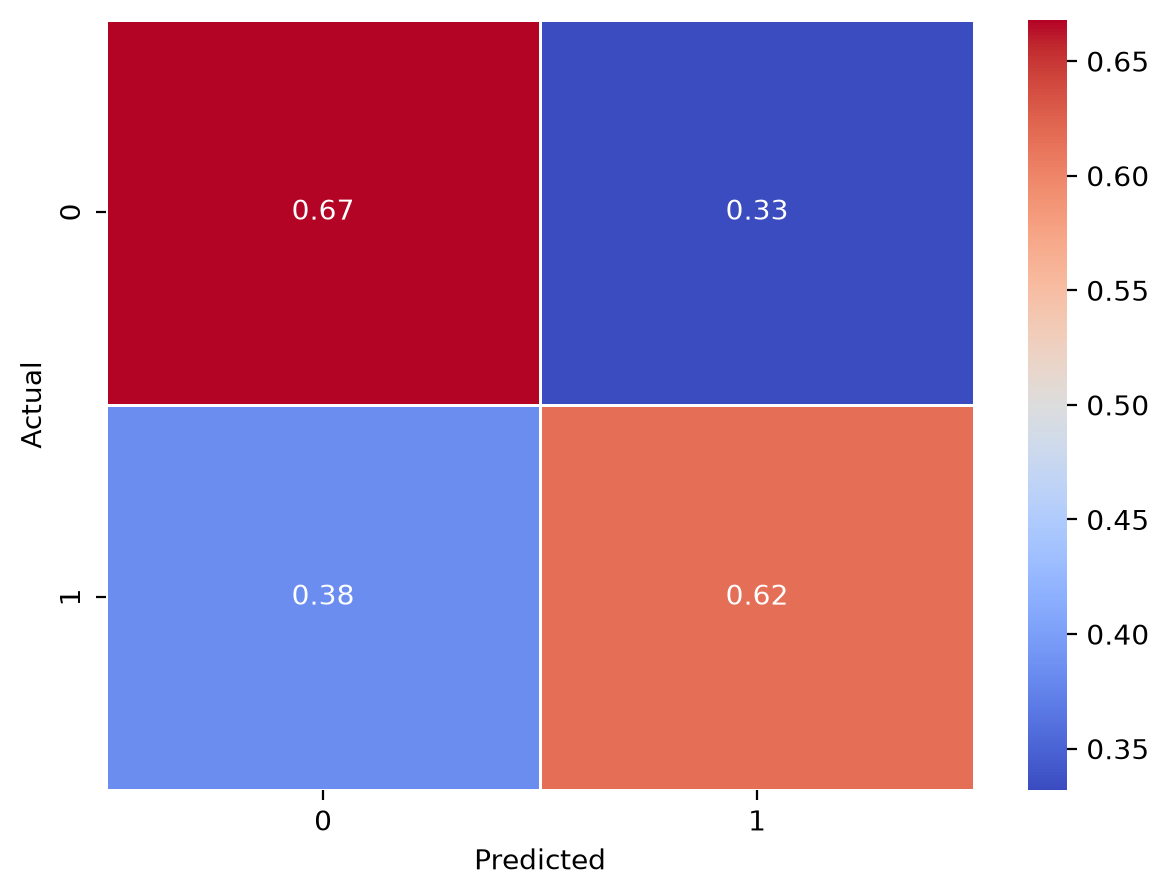

In [32]:
from common.evaluation_plots import show_norm_conf_mx

show_norm_conf_mx(y=Y_test, pred=test_pred)

## ROC Curve

In [33]:
from sklearn.dummy import DummyClassifier

# Dummy 모델
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, Y_train)

pred_dummy = dummy.predict_proba(X_test)[:, 1]

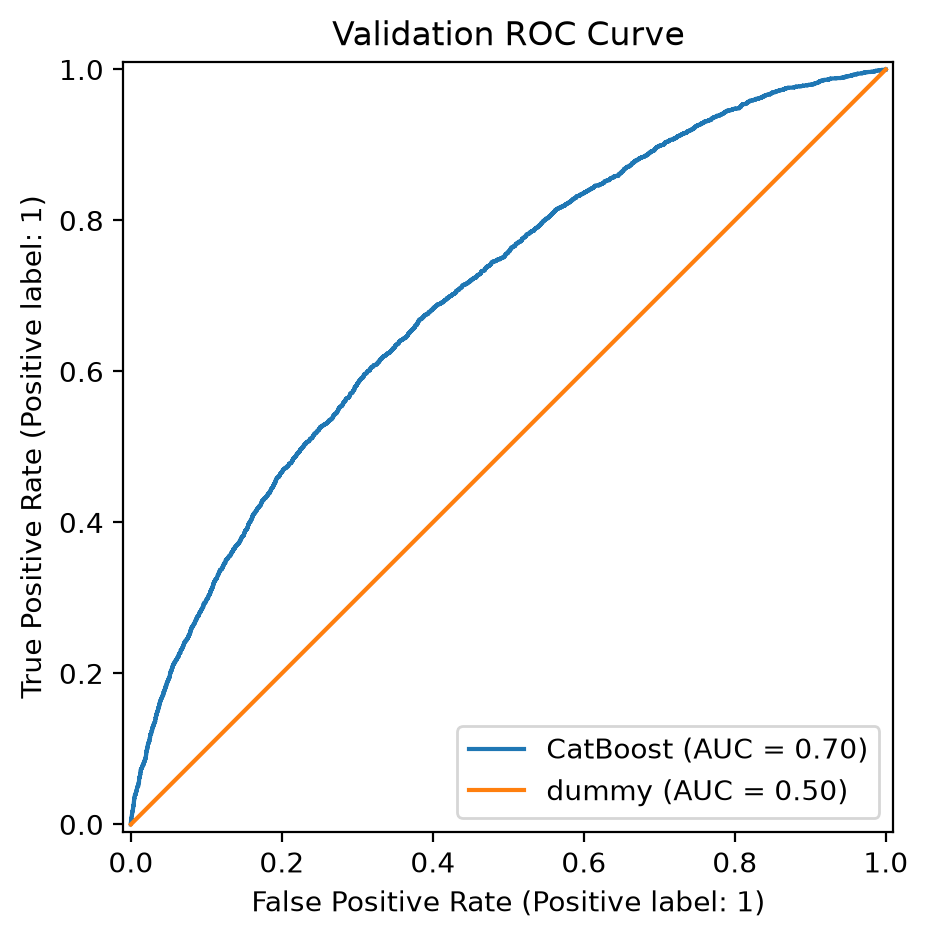

In [34]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(Y_test, test_proba, name='CatBoost',ax=ax)
RocCurveDisplay.from_predictions(Y_test, pred_dummy, name='dummy', ax=ax)
plt.title("Validation ROC Curve")
plt.show()

## XAI (SHAP)

In [35]:
import shap

# 학습된 모델을 넣는다.
explainer = shap.TreeExplainer(cat_model)
# 학습된 모델을 갖고 X_val를 분석
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values = shap_values[-1]

shap_values = np.asarray(shap_values)

In [36]:
shap_values[1].shape , X_test.shape

((14,), (14987, 14))

C:\Users\iyuri\AppData\Local\Temp\ipykernel_19604\2940161786.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


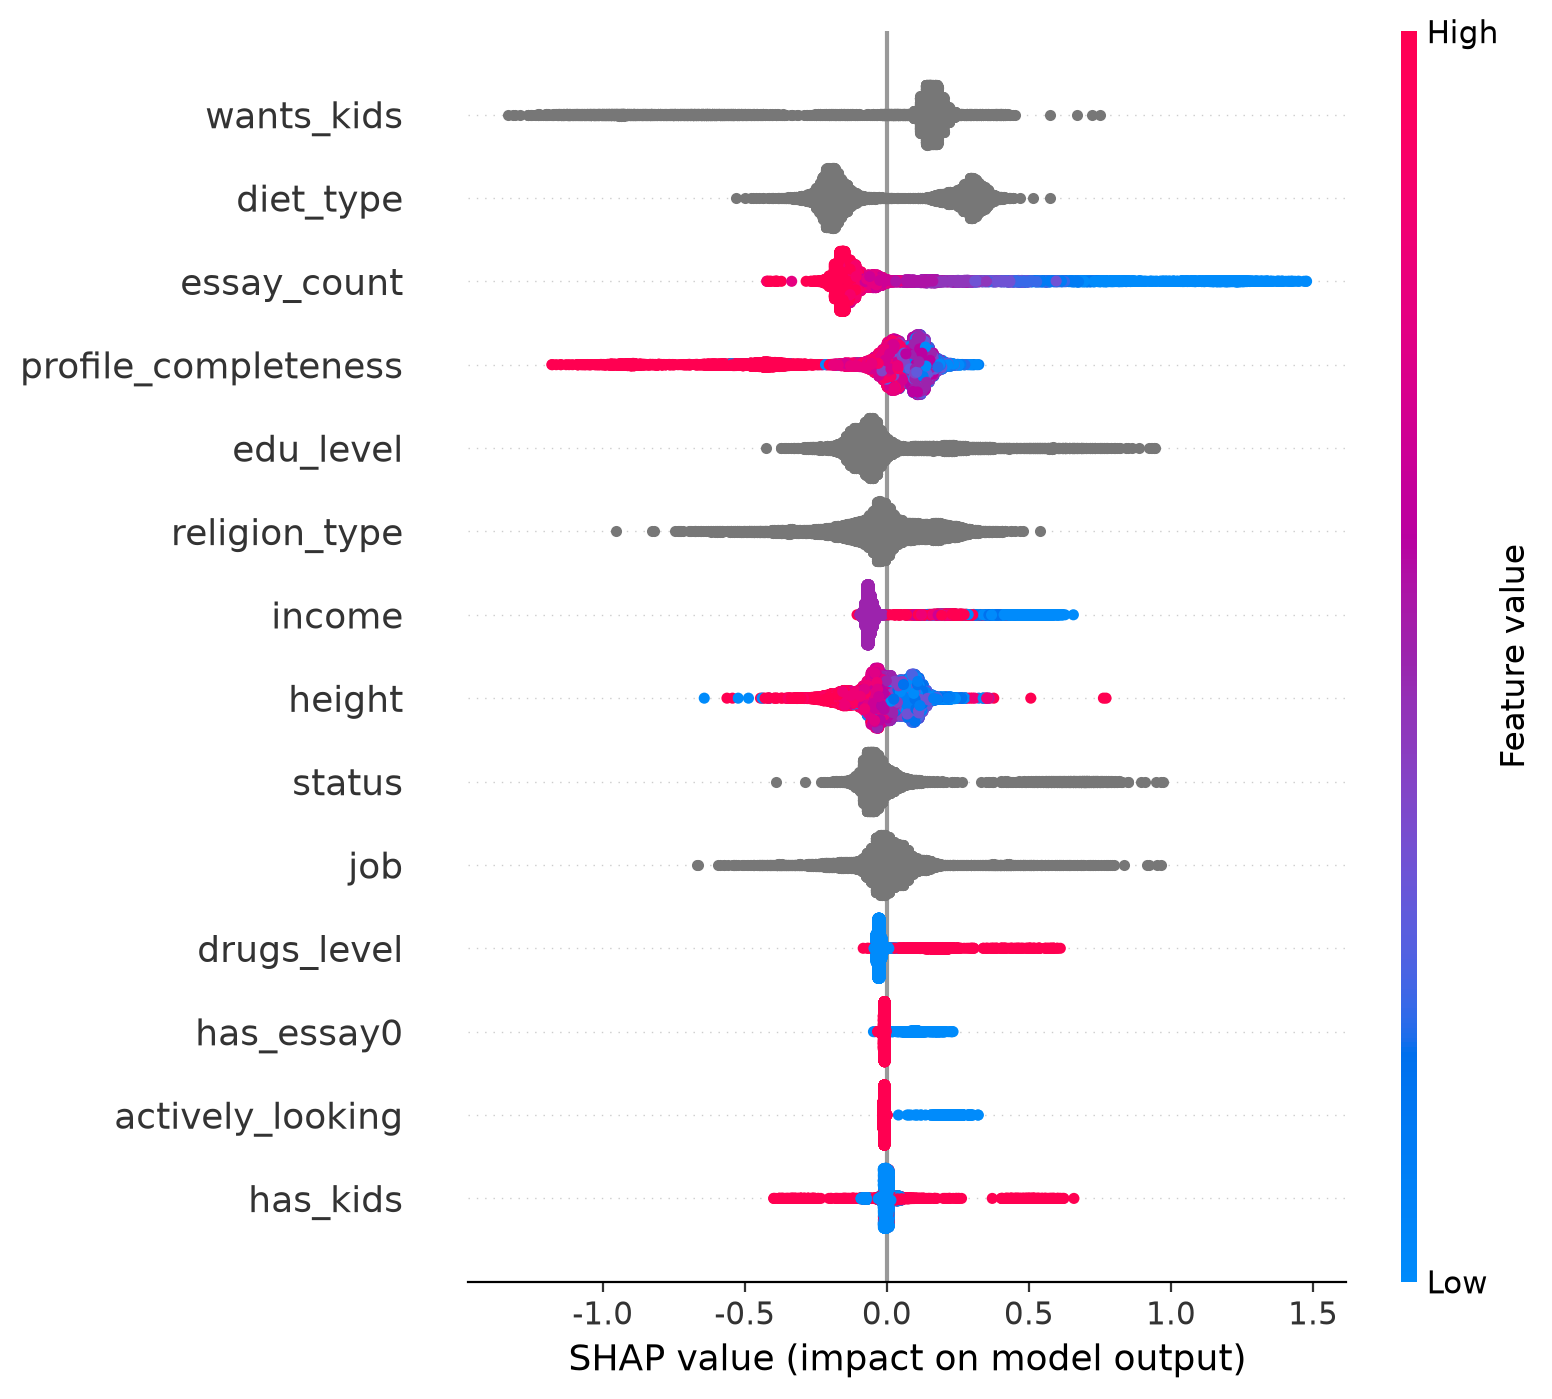

In [37]:
shap.summary_plot(shap_values, X_test)

C:\Users\iyuri\AppData\Local\Temp\ipykernel_19604\3237810805.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


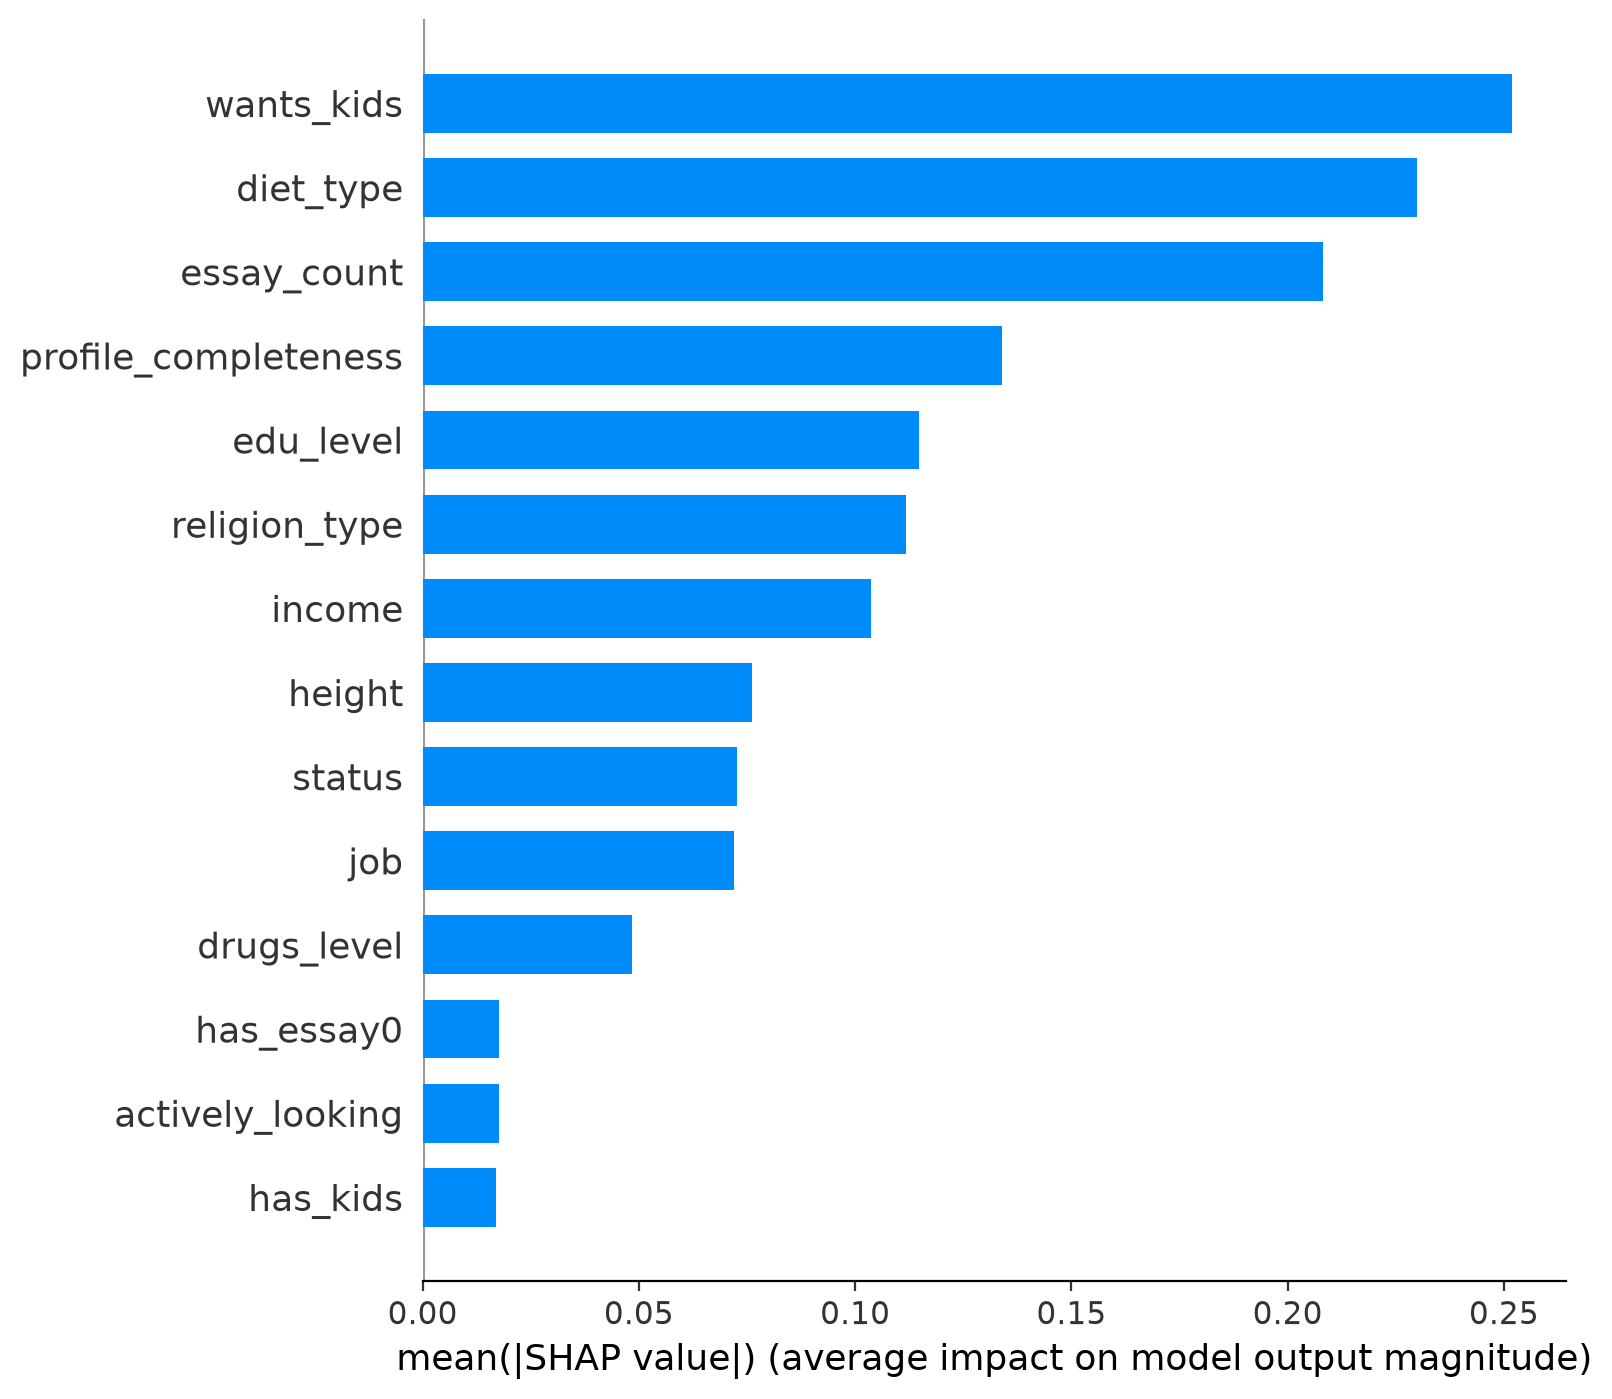

In [38]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [39]:
explainer=shap.TreeExplainer(cat_model)
sv=explainer.shap_values(X_test)
if isinstance(sv,list): sv=sv[-1]
sv=np.asarray(sv)
shap_rank=pd.DataFrame({'feature':X_test.columns,'mean_abs_shap':np.abs(sv).mean(axis=0)}).sort_values('mean_abs_shap',ascending=False)
shap_rank.head(30)


,feature,mean_abs_shap
6,wants_kids,0.251754
8,diet_type,0.229872
2,essay_count,0.208150
3,profile_completeness,0.133974
5,edu_level,0.114863
4,religion_type,0.111646
13,income,0.103737
11,height,0.076115
12,status,0.072693
10,job,0.071881


C:\Users\iyuri\AppData\Local\Temp\ipykernel_19604\281312856.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


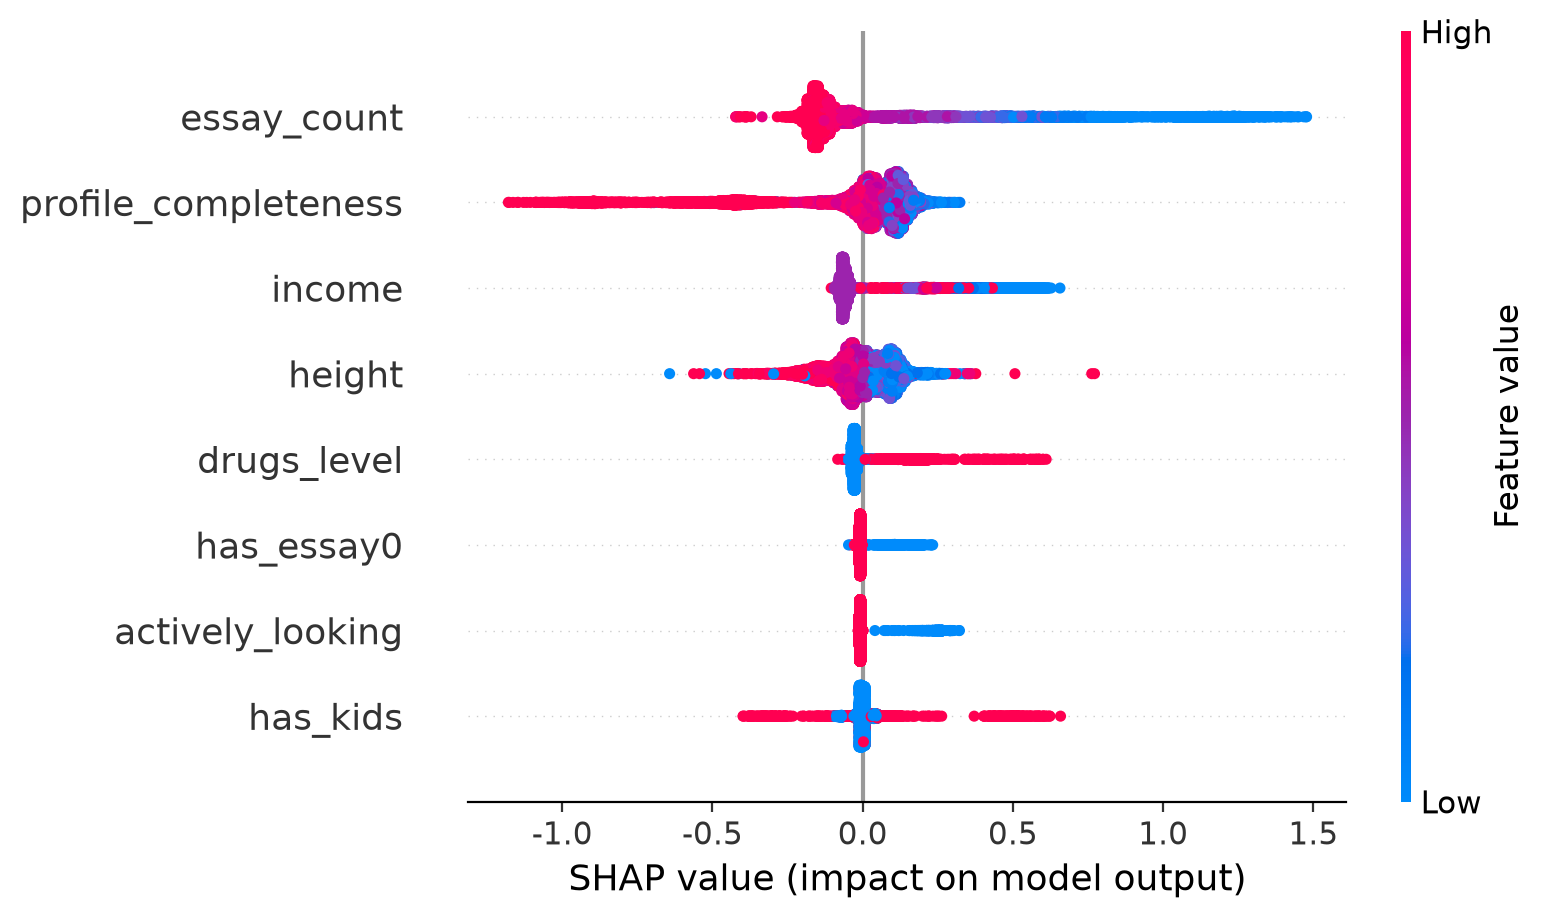

In [40]:
# 수치형 feature만 보기
selected_features = X_test.select_dtypes(include=np.number).columns.tolist()
# X_val에서 해당 feature의 위치
selected_idx = [X_test.columns.get_loc(col) for col in selected_features]

# 원하는 feature만 SHAP plot
shap.summary_plot(
    shap_values[:, selected_idx],
    X_test[selected_features]
)

C:\Users\iyuri\AppData\Local\Temp\ipykernel_19604\3730614114.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


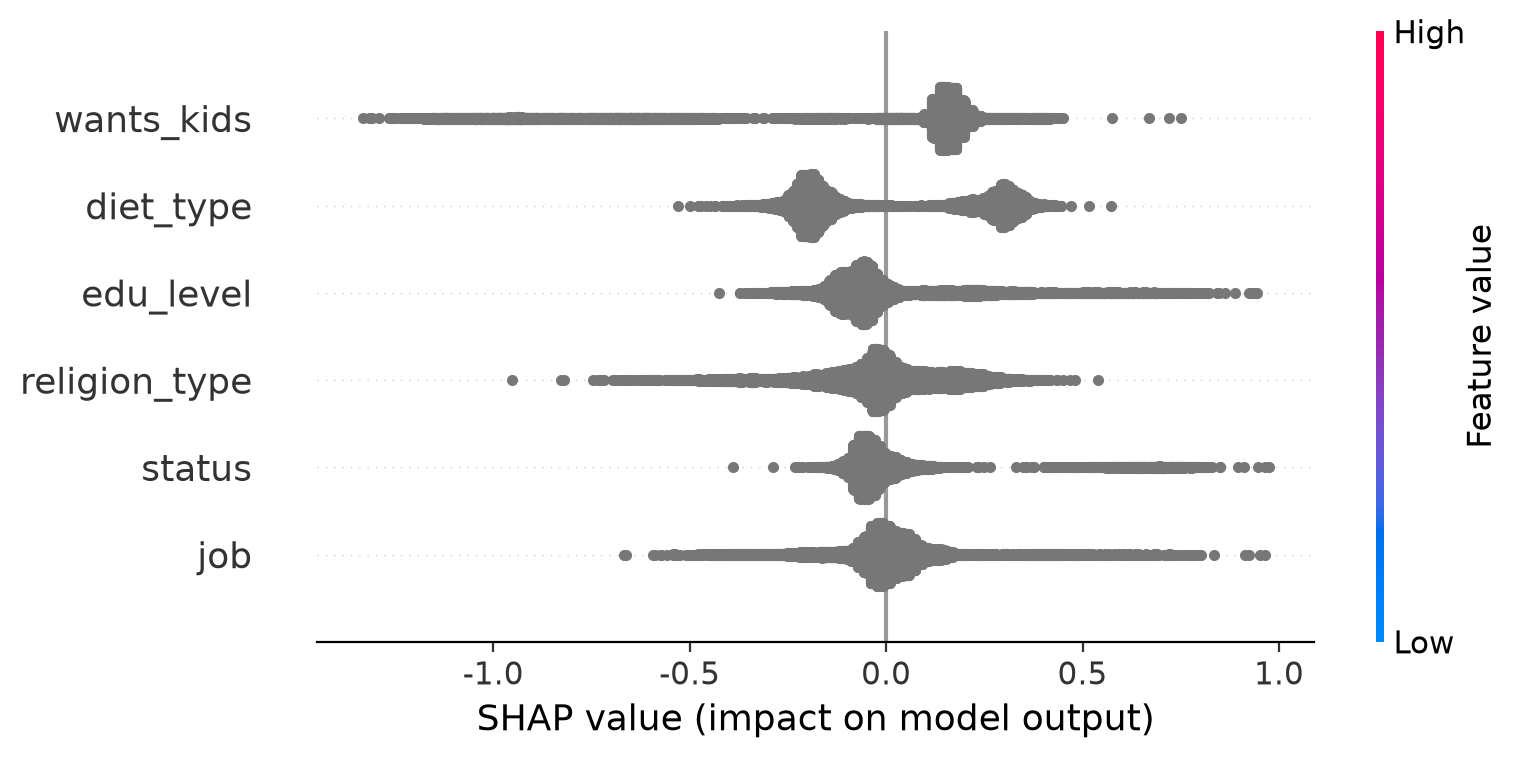

In [41]:
# 범주형 feature만 보기
selected_features = X_test.select_dtypes(exclude=np.number).columns.tolist()
selected_idx = [X_test.columns.get_loc(col) for col in selected_features]

shap.summary_plot(
    shap_values[:, selected_idx],
    X_test[selected_features]
)

# 모델 저장

In [42]:
from datetime import datetime
from pathlib import Path

# 진짜 저장할거야? 진짜?
# 진짜루??????
answer = input("모델을 저장하려면 'Y'를 눌러주세요: ")

if answer.upper() == "Y":
    # 저장 폴더 생성
    Path("models").mkdir(parents=True, exist_ok=True)

    # 현재 시각으로 파일명 생성
    timestamp = datetime.now().strftime("%m_%d_%H_%M")
    model_path = f"models/okcupid_model_{timestamp}.cbm"

    # 모델 저장
    cat_model.save_model(model_path)
    print(f"저장 완료: {model_path}")


# # 로드는 아래와 같이 해주세요.
# model = CatBoostClassifier()
# model.load_model("models/okcupid_model.cbm")